# Testing Equivalence — experiments

The two implication tests are in `equivalence.py`, the pair construction in `pairs.py` and the timing harness in `bench.py`. This notebook runs them and produces the tables and figures used in the report.

In [1]:
%load_ext autoreload
%autoreload 2

import platform
import sys

import pysat

print(sys.version)
print(platform.platform())
print(platform.processor())
print("python-sat", pysat.__version__)

3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
Windows-10-10.0.26200-SP0
Intel64 Family 6 Model 186 Stepping 2, GenuineIntel
python-sat 1.9.dev7


## 1. Correctness on small cases

Formulas small enough to enumerate, so the verdict can be checked against brute force. Both approaches must agree with it.

In [2]:
import pandas as pd

from equivalence import Cnf, Verdict, brute_force_relationship, read_dimacs, relationship

def cnf(n, cs):
    return Cnf(n_vars=n, clauses=[list(c) for c in cs])

cases = [
    ("identical",        cnf(2, [[1, 2]]),        cnf(2, [[1, 2]])),
    ("psi weaker",       cnf(2, [[1], [2]]),      cnf(2, [[1]])),
    ("psi stronger",     cnf(2, [[1]]),           cnf(2, [[1], [2]])),
    ("unrelated",        cnf(2, [[1]]),           cnf(2, [[2]])),
    ("phi unsatisfiable",cnf(2, [[1], [-1]]),     cnf(2, [[2]])),
    ("both unsatisfiable",cnf(2, [[1], [-1]]),    cnf(2, [[2], [-2]])),
    ("psi has no clauses",cnf(2, [[1]]),          cnf(2, [])),
    ("tautology in psi", cnf(2, [[1]]),           cnf(2, [[1, -1], [1]])),
    ("resolvent added",  cnf(3, [[1, 2], [-1, 3]]), cnf(3, [[1, 2], [-1, 3], [2, 3]])),
]

rows = []
for name, phi, psi in cases:
    ref = brute_force_relationship(phi, psi)
    t = relationship(phi, psi, "tseitin").verdict
    i = relationship(phi, psi, "incremental").verdict
    rows.append({"case": name, "brute force": ref.value,
                 "tseitin": t.value, "incremental": i.value,
                 "agree": ref == t == i})

df_small = pd.DataFrame(rows)
print("all agree:", bool(df_small.agree.all()))
df_small

all agree: True


,case,brute force,tseitin,incremental,agree
0,identical,phi <=> psi,phi <=> psi,phi <=> psi,True
1,psi weaker,phi => psi,phi => psi,phi => psi,True
2,psi stronger,phi <= psi,phi <= psi,phi <= psi,True
3,unrelated,no relationship,no relationship,no relationship,True
4,phi unsatisfiable,phi => psi,phi => psi,phi => psi,True
5,both unsatisfiable,phi <=> psi,phi <=> psi,phi <=> psi,True
6,psi has no clauses,phi => psi,phi => psi,phi => psi,True
7,tautology in psi,phi <=> psi,phi <=> psi,phi <=> psi,True
8,resolvent added,phi <=> psi,phi <=> psi,phi <=> psi,True


## 2. Benchmarks

Three instances from each SATLIB family, chosen as the smallest in the family so the number of calls stays workable.

In [3]:
import os

from bench import families, instances

rows = []
for fam in families():
    for path in instances(fam):
        f = read_dimacs(path)
        rows.append({"family": fam, "instance": os.path.basename(path),
                     "vars": f.n_vars, "clauses": f.n_clauses})

df_bench = pd.DataFrame(rows)
print(f"{df_bench.family.nunique()} families, {len(df_bench)} instances, "
      f"{df_bench.clauses.min()} to {df_bench.clauses.max()} clauses")
df_bench.groupby("family").agg(instances=("instance", "count"),
                               vars=("vars", "max"),
                               clauses=("clauses", "max"))

25 families, 74 instances, 80 to 41207 clauses


,instances,vars,clauses
family,,,
aim,3,50,80
ais,3,181,3151
beijing,3,590,1422
bf,3,2177,6768
blocksworld,3,459,4675
bmc,3,9396,41207
bms,3,100,429
cbs,3,100,403
dubois,3,66,176


## 3. The sweep

Every instance is mutated six ways and each resulting pair is tested with both approaches. Every pair runs in the same process. A child process per pair would cost far more in interpreter start-up and pickling than the pair itself takes, so the incremental approach stops itself at a deadline instead, and the Tseitin approach, which is a single call and cannot be interrupted, is held back by a size guard.

In [4]:
from bench import BUDGET, sweep, to_records

rows = sweep(budget=60.0, verbose=False)
df = pd.DataFrame(to_records(rows))
df.to_csv("results.csv", index=False)

print(f"{len(df)} runs, {df.timed_out.sum()} timed out, {df.error.notna().sum()} errored")
df.head(12)

888 runs, 0 timed out, 0 errored


,family,instance,n_vars,n_clauses,mutation,intended,method,solver,verdict,calls,aux_vars,build_time,load_time,solve_time,total_time,timed_out,error,matched_intent
0,aim,aim-50-1_6-no-1.cnf,50,80,identical,phi <=> psi,tseitin,cadical153,phi <=> psi,2,160,0.000116,0.001766,0.000281,0.002163,False,None,True
1,aim,aim-50-1_6-no-1.cnf,50,80,identical,phi <=> psi,incremental,cadical153,phi <=> psi,160,0,0.000000,0.001231,0.000779,0.002011,False,None,True
2,aim,aim-50-1_6-no-1.cnf,50,80,shuffled,phi <=> psi,tseitin,cadical153,phi <=> psi,2,160,0.000067,0.001507,0.000358,0.001932,False,None,True
3,aim,aim-50-1_6-no-1.cnf,50,80,shuffled,phi <=> psi,incremental,cadical153,phi <=> psi,160,0,0.000000,0.001402,0.000786,0.002188,False,None,True
4,aim,aim-50-1_6-no-1.cnf,50,80,resolvent added,phi <=> psi,tseitin,cadical153,phi <=> psi,2,161,0.000102,0.001742,0.000290,0.002134,False,None,True
5,aim,aim-50-1_6-no-1.cnf,50,80,resolvent added,phi <=> psi,incremental,cadical153,phi <=> psi,161,0,0.000000,0.001413,0.000772,0.002184,False,None,True
6,aim,aim-50-1_6-no-1.cnf,50,80,clause dropped,phi => psi,tseitin,cadical153,phi => psi,2,159,0.000069,0.001531,0.000248,0.001848,False,None,True
7,aim,aim-50-1_6-no-1.cnf,50,80,clause dropped,phi => psi,incremental,cadical153,phi => psi,91,0,0.000000,0.001224,0.000448,0.001671,False,None,True
8,aim,aim-50-1_6-no-1.cnf,50,80,clause added,phi <= psi,tseitin,cadical153,phi <=> psi,2,161,0.000067,0.001512,0.000252,0.001830,False,None,False
9,aim,aim-50-1_6-no-1.cnf,50,80,clause added,phi <= psi,incremental,cadical153,phi <=> psi,161,0,0.000000,0.001219,0.000761,0.001980,False,None,False


## 4. The two approaches must agree

Both compute the same relation, so on every pair they have to return the same verdict. This is the strongest correctness check available at this scale, since the formulas are far too large to enumerate.

In [5]:
ok = df[~df.timed_out & df.error.isna()]
wide = ok.pivot_table(index=["family", "instance", "mutation"],
                      columns="method", values="verdict", aggfunc="first")
both = wide.dropna()
disagree = both[both.tseitin != both.incremental]

print(f"pairs tested by both approaches: {len(both)}")
print(f"disagreements: {len(disagree)}")
disagree

pairs tested by both approaches: 444
disagreements: 0


,,method,incremental,tseitin
family,instance,mutation,,


## 5. Which verdicts the mutations actually produce

Each mutation has an intended verdict but only the measurement decides. Dropping a clause that the rest of the formula already implies leaves the two formulas equivalent, and that happens often on small dense instances.

In [6]:
inc = ok[ok.method == "incremental"]

print("verdicts per mutation")
print(pd.crosstab(inc.mutation, inc.verdict).to_string())
print()
print("how often the intended verdict was the measured one")
print(inc.groupby("mutation").matched_intent.mean().round(3).to_string())

verdicts per mutation
verdict          no relationship  phi <= psi  phi <=> psi  phi => psi
mutation                                                             
clause added                   0          23           51           0
clause dropped                 0           0           42          32
identical                      0           0           74           0
literal flipped               15          12           30          17
resolvent added                0           0           74           0
shuffled                       0           0           74           0

how often the intended verdict was the measured one
mutation
clause added       0.311
clause dropped     0.432
identical          1.000
literal flipped    0.203
resolvent added    1.000
shuffled           1.000


## 6. Cost of the two approaches

Times are split into building the clause list in Python, loading it into the solver, and the search itself, so no part of the run is left unmeasured.

In [7]:
summary = ok.groupby("method").agg(
    runs=("total_time", "count"),
    calls_median=("calls", "median"),
    calls_max=("calls", "max"),
    aux_vars_max=("aux_vars", "max"),
    build=("build_time", "sum"),
    load=("load_time", "sum"),
    solve=("solve_time", "sum"),
    total=("total_time", "sum"),
).round(3)
summary

,runs,calls_median,calls_max,aux_vars_max,build,load,solve,total
method,,,,,,,,
incremental,444,859.0,82415,0,0.000,3.248,23.963,27.211
tseitin,444,2.0,2,82415,7.809,8.972,168.288,185.068


In [8]:
per_family = ok.pivot_table(index="family", columns="method",
                            values="total_time", aggfunc="sum").round(3)
per_family["ratio tseitin/incremental"] = (
    per_family["tseitin"] / per_family["incremental"]).round(2)
per_family = per_family.join(
    ok[ok.method == "incremental"].groupby("family").n_clauses.max().rename("clauses"))
per_family.sort_values("clauses")

,incremental,tseitin,ratio tseitin/incremental,clauses
family,,,,
aim,0.038,0.038,1.00,80
uf20-91,0.088,0.083,0.94,91
pret,0.083,0.073,0.88,161
dubois,0.055,0.060,1.09,176
uuf50-218,0.134,0.154,1.15,218
uf50-218,0.149,0.158,1.06,218
parity,0.163,0.182,1.12,270
pigeon-hole,0.326,0.495,1.52,297
flat30-60,0.070,0.066,0.94,300


## 7. Early exit

The incremental approach stops at the first satisfiable query, so a pair that turns out unrelated can finish after a single call, while a pair that really is equivalent has to work through every clause.

In [9]:
inc = ok[ok.method == "incremental"].copy()
inc["calls_per_clause"] = inc.calls / (2 * inc.n_clauses)

print(inc.groupby("verdict").agg(
    runs=("calls", "count"),
    calls_median=("calls", "median"),
    fraction_of_clauses_queried=("calls_per_clause", "median"),
).round(3).to_string())

                 runs  calls_median  fraction_of_clauses_queried
verdict                                                         
no relationship    15         596.0                        0.749
phi <= psi         35         987.0                        1.000
phi <=> psi       345         860.0                        1.000
phi => psi         49         579.0                        0.765


## 8. Figures

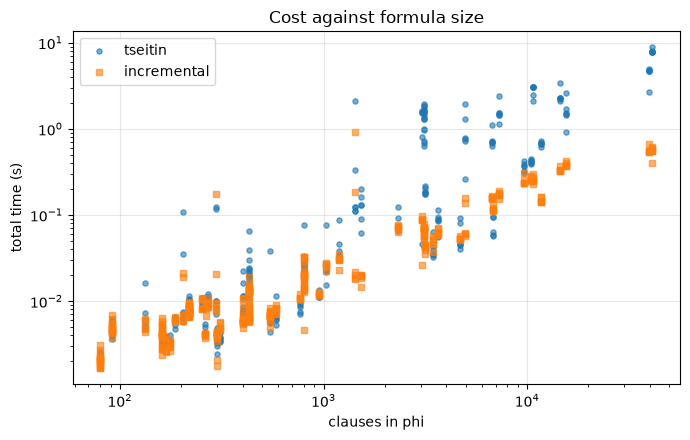

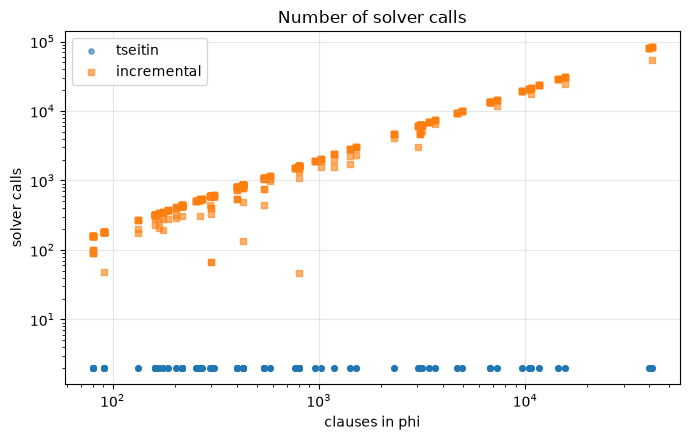

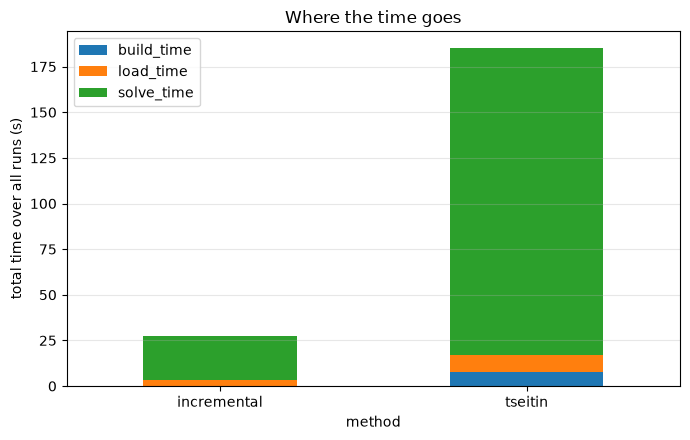

In [10]:
from pathlib import Path

import matplotlib.pyplot as plt

figdir = Path("../report/figures")
figdir.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(7, 4.5))
for method, marker in [("tseitin", "o"), ("incremental", "s")]:
    sub = ok[ok.method == method]
    ax.scatter(sub.n_clauses, sub.total_time, s=14, marker=marker, alpha=0.6, label=method)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("clauses in phi")
ax.set_ylabel("total time (s)")
ax.set_title("Cost against formula size")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(figdir / "time_vs_size.pdf")
plt.show()

fig, ax = plt.subplots(figsize=(7, 4.5))
for method, marker in [("tseitin", "o"), ("incremental", "s")]:
    sub = ok[ok.method == method]
    ax.scatter(sub.n_clauses, sub.calls, s=14, marker=marker, alpha=0.6, label=method)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("clauses in phi")
ax.set_ylabel("solver calls")
ax.set_title("Number of solver calls")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(figdir / "calls_vs_size.pdf")
plt.show()

fig, ax = plt.subplots(figsize=(7, 4.5))
phases = ok.groupby("method")[["build_time", "load_time", "solve_time"]].sum()
phases.plot(kind="bar", stacked=True, ax=ax)
ax.set_ylabel("total time over all runs (s)")
ax.set_title("Where the time goes")
ax.grid(True, alpha=0.3, axis="y")
plt.xticks(rotation=0)
fig.tight_layout()
fig.savefig(figdir / "phases.pdf")
plt.show()